### Abstract
Many small online retailers and new entrants to the online retail sector are keen to practice data mining and consumer-centric marketing in their businesses yet technically lack the necessary knowledge and expertise to do so. In this article a case study of using data mining techniques in customer-centric business intelligence for an online retailer is presented. The main purpose of this analysis is to help the business better understand its customers and therefore conduct customer-centric marketing more effectively. On the basis of the Recency, Frequency, and Monetary model, customers of the business have been segmented into various meaningful groups using the k-means clustering algorithm and decision tree induction, and the main characteristics of the consumers in each segment have been clearly identified. Accordingly a set of recommendations is further provided to the business on consumer-centric marketing. SAS Enterprise Guide and SAS Enterprise Miner are used in the present study.

| Variable Name | Role    | Type        | Description                                                                 | Units    |
|--------------|---------|-------------|-----------------------------------------------------------------------------|----------|
| InvoiceNo    | ID      | Categorical | A 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'C', it indicates a cancellation |          | No             |
| StockCode    | ID      | Categorical | A 5-digit integral number uniquely assigned to each distinct product        |          |
| Description  | Feature | Categorical | Product name                                                                |          |
| Quantity     | Feature | Integer     | The quantities of each product (item) per transaction                        |          |
| InvoiceDate  | Feature | Date        | The day and time when each transaction was generated                         |          |
| UnitPrice    | Feature | Continuous  | Product price per unit                                                       | Sterling |
| CustomerID   | Feature | Categorical | A 5-digit integral number uniquely assigned to each customer                 |          |
| Country      | Feature | Categorical | The name of the country where each customer resides                          |          |

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [229]:
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [230]:
df.shape

(541909, 8)

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [232]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [233]:
# Findind duplicates, missing values and outliers
print(f'Total duplicated values: {df.duplicated().sum()}')
print(f'Total Null values: {df.isnull().sum()}')

Total duplicated values: 5268
Total Null values: InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [234]:
print(f'Percentage of duplicated values: {df.duplicated().sum() / len(df) * 100:.2f}%')

Percentage of duplicated values: 0.97%


As we can see, the total number of duplicated values represents less than 1% of the total data, so we can delete them.

In [235]:
df.drop_duplicates(inplace=True)

In [236]:
print(f'Percentage of null values: {df['CustomerID'].isnull().sum() / len(df) * 100:.2f}%')

Percentage of null values: 25.16%


Given the nature of the task, cohort identification is required to remove records without a customer ID, which account for 25% of the dataset.

In [237]:
df = df.dropna(subset=['CustomerID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


In [238]:
df.shape

(401604, 8)

In [239]:
df['StockCode'].nunique(), df['Description'].nunique()

(3684, 3896)

In [240]:
(df.groupby('StockCode')['Description'].nunique() > 1).sum()

np.int64(213)

There are some StockCode with different descriptions

In [241]:
# Lets look for negative values in Quantity and UnitPrice

np.logical_or(df['Quantity'] <=0, (df['UnitPrice'] <=0)).value_counts(normalize=True)

False    0.977809
True     0.022191
Name: proportion, dtype: float64

this means:

97% of registers has an ammount and price valid

3% of registers has an ammount ≤ 0

In [242]:
# df = df.query('Quantity > 0 and UnitPrice > 0') this does exactly the same
df= df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df.shape

(392692, 8)

Now the dataset looks ready to work with: there are no duplicates, no null values, and the data types are correct for each variable.

Now lets work with the Cohorts

This could be work as other way to do it

-# Lets to create a new column with the invoiceDate as datetime
df['OrderDay']= df['InvoiceDate'].dt.date
df['OrderMonth']= df['InvoiceDate'].dt.to_period('M')

-# Transfor the OrderDay type to datetime format
df['OrderDay']= pd.to_datetime(df['OrderDay'])
df.info()

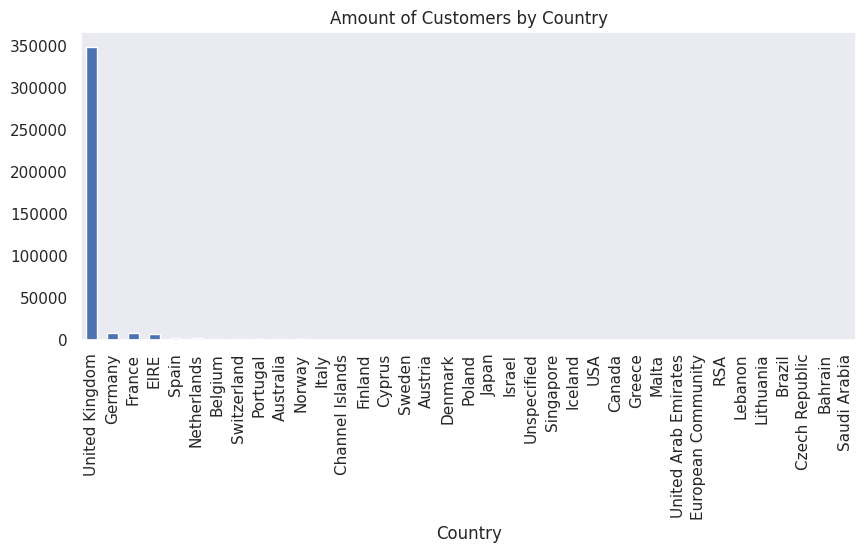

In [243]:
df['Country'].value_counts().plot.bar(figsize=(10,4))
plt.title('Amount of Customers by Country')
plt.show()

Due to the distributions by country, it seems appropriate to focus the analysis on the United Kingdom.

In [244]:
df_uk = df[df['Country']=='United Kingdom']
df_uk.shape

(349203, 8)

In [245]:
# Lets clean the StockCode column

df_uk['StockCode']=df_uk['StockCode'].str.strip()
df_uk['StockCode'].nunique()

/tmp/ipykernel_3459/3273704729.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uk['StockCode']=df_uk['StockCode'].str.strip()


866

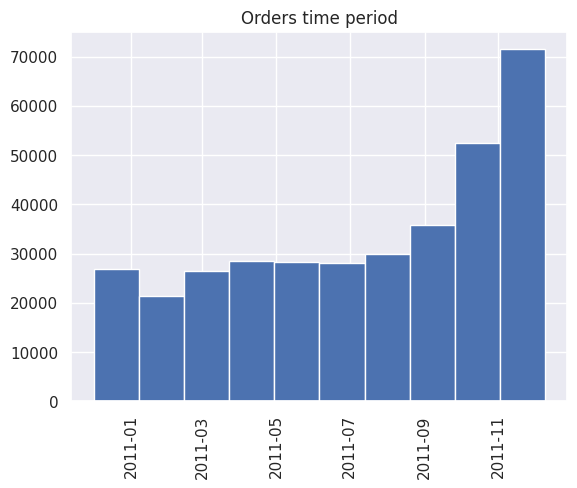

First_order 2010-12-01 08:26:00
Last_order 2011-12-09 12:49:00


In [246]:
# Period time of the data

df_uk['InvoiceDate'].hist()
plt.title('Orders time period')
plt.xticks(rotation=90)
plt.show()

print(f'First_order {df_uk['InvoiceDate'].min()}')
print(f'Last_order {df_uk['InvoiceDate'].max()}')

In [247]:
# Lets find the firs orders
first_order = df_uk.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_order.columns = ['CustomerID','first_activity']
first_order['First_day_activity'] = pd.to_datetime(first_order['first_activity'].dt.date)
first_order.head()

,CustomerID,first_activity,First_day_activity
0,12346.0,2011-01-18 10:01:00,2011-01-18
1,12747.0,2010-12-05 15:38:00,2010-12-05
2,12748.0,2010-12-01 12:48:00,2010-12-01
3,12749.0,2011-05-10 15:25:00,2011-05-10
4,12820.0,2011-01-17 12:34:00,2011-01-17


In [248]:
# Monthly order

first_order['First_month_activity'] = first_order['first_activity'].dt.to_period('M').dt.start_time
first_order.head()

,CustomerID,first_activity,First_day_activity,First_month_activity
0,12346.0,2011-01-18 10:01:00,2011-01-18,2011-01-01
1,12747.0,2010-12-05 15:38:00,2010-12-05,2010-12-01
2,12748.0,2010-12-01 12:48:00,2010-12-01,2010-12-01
3,12749.0,2011-05-10 15:25:00,2011-05-10,2011-05-01
4,12820.0,2011-01-17 12:34:00,2011-01-17,2011-01-01


In [249]:
# Merge the datasets

df_uk = df_uk.merge(first_order,on= 'CustomerID')
df_uk.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,first_activity,First_day_activity,First_month_activity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,2010-12-01,2010-12-01
1,536365,NaN,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010-12-01,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,2010-12-01,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010-12-01,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,2010-12-01,2010-12-01


<Axes: xlabel='InvoiceDate'>

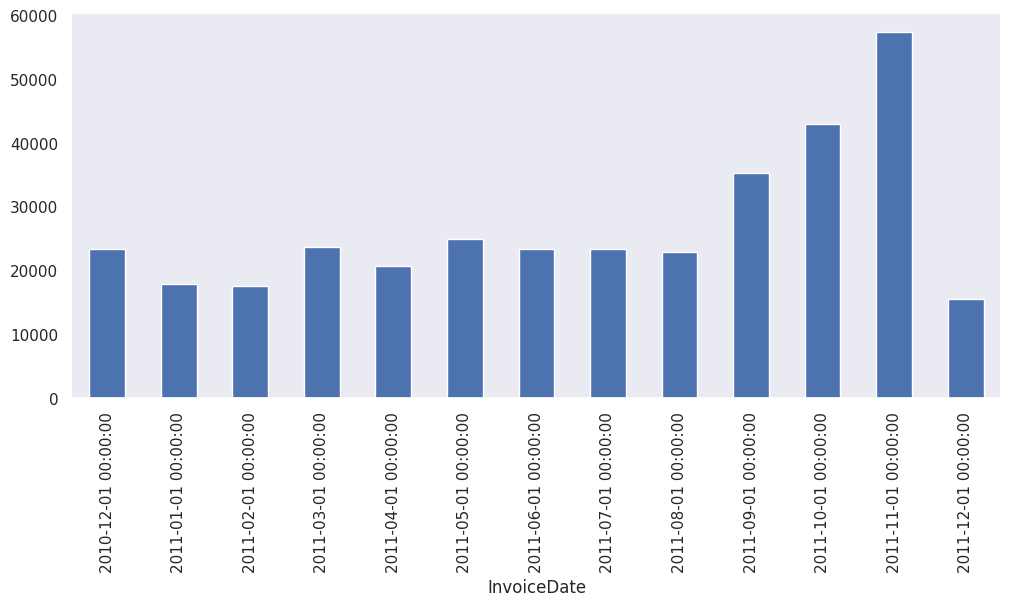

In [250]:
# lets take a look of the amount of orders across the time
df_uk['InvoiceDate'].dt.to_period('M').dt.start_time.value_counts().sort_index().plot.bar(figsize=(12,5))

In [251]:
# Life cycle

df_uk['Cohort_M'] = (df_uk['InvoiceDate'].dt.month - df_uk['First_month_activity'].dt.month)

# This Code avoid the negative month on the cohort column 
df_uk['Cohort_M'] += 12 * (df_uk['InvoiceDate'].dt.year - df_uk['First_month_activity'].dt.year)

In [252]:
# Now we are going to create the cohort table

cohort= df_uk.groupby(['First_month_activity', 'Cohort_M']).agg({'CustomerID':'nunique'}).reset_index()
cohort.head()

,First_month_activity,Cohort_M,CustomerID
0,2010-12-01,0,815
1,2010-12-01,1,289
2,2010-12-01,2,263
3,2010-12-01,3,304
4,2010-12-01,4,293


In [253]:
# lets find the initial numbers of users on the 0 week

initial_users= cohort[cohort['Cohort_M']== 0][['First_month_activity','CustomerID']]

# Rename Columns
initial_users= initial_users.rename(columns={'CustomerID':'Cohort_users'})

# Merge both datasets

cohort= cohort.merge(initial_users, on= 'First_month_activity')

cohort.sample(5)

,First_month_activity,Cohort_M,CustomerID,Cohort_users
1,2010-12-01,1,289,815
48,2011-04-01,2,56,277
15,2011-01-01,2,93,358
5,2010-12-01,5,323,815
79,2011-08-01,3,34,141


In [254]:
# Retention rate

cohort['Retention']= cohort['CustomerID'] / cohort['Cohort_users']
cohort.sample(5)

,First_month_activity,Cohort_M,CustomerID,Cohort_users,Retention
52,2011-04-01,6,61,277,0.220217
44,2011-03-01,8,119,419,0.284010
88,2011-11-01,0,297,297,1.000000
20,2011-01-01,7,87,358,0.243017
8,2010-12-01,8,289,815,0.354601


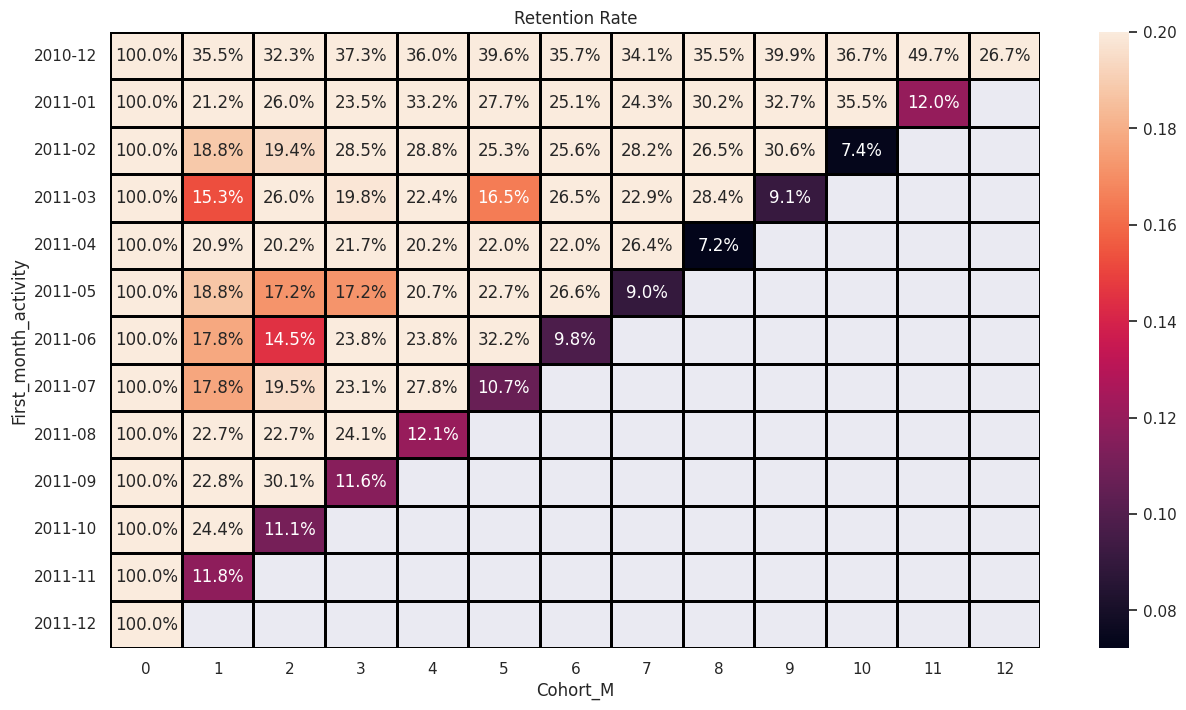

In [255]:
# graphic the results

# adjust dates for a clear graphic
cohort['First_month_activity'] = cohort['First_month_activity'].dt.strftime('%Y-%m')

# Create the Pivot 
retention_pivot = cohort.pivot_table(
    index='First_month_activity',
    columns='Cohort_M',
    values='Retention',
    aggfunc='sum'
)

sns.set(style='dark')
plt.figure(figsize=(15,8))
plt.title('Retention Rate')
sns.heatmap(retention_pivot, annot=True, fmt='.1%', linewidths=1, linecolor= 'black',vmax=0.2,cmap='rocket')
plt.show()

In [256]:
sticky_factor = df_uk.copy([['InvoiceDate','CustomerID']])
sticky_factor['month']= sticky_factor['InvoiceDate'].dt.to_period('M').dt.start_time
sticky_factor['week']= sticky_factor['InvoiceDate'].dt.isocalendar().week
sticky_factor['date']= sticky_factor['InvoiceDate'].dt.date

mau_total = sticky_factor.groupby('month',).agg({'CustomerID':'nunique'}).mean()
wau_total = sticky_factor.groupby('week',).agg({'CustomerID':'nunique'}).mean()
dau_total = sticky_factor.groupby('date',).agg({'CustomerID':'nunique'}).mean()

print(f'Total de usuarios por mes: {int(mau_total.iloc[0])}')
print(f'Total de usuarios por semana: {int(wau_total.iloc[0])}')
print(f'Total de usuarios por dia: {int(dau_total.iloc[0])}')

Total de usuarios por mes: 906
Total de usuarios por semana: 279
Total de usuarios por dia: 49


In [257]:
sticky_mau = (dau_total/mau_total)*100
sticky_wau = (dau_total/wau_total)*100

print(sticky_mau)
print(sticky_wau)

CustomerID    5.456027
dtype: float64
CustomerID    17.710578
dtype: float64


This metrics suggest:

Infrequent usage, Users log in occasionally, Low daily retention.

In [258]:
# lests take a look how much do the custumers spends 

df_uk['Total_spend']= df_uk['UnitPrice']*df_uk['Quantity']

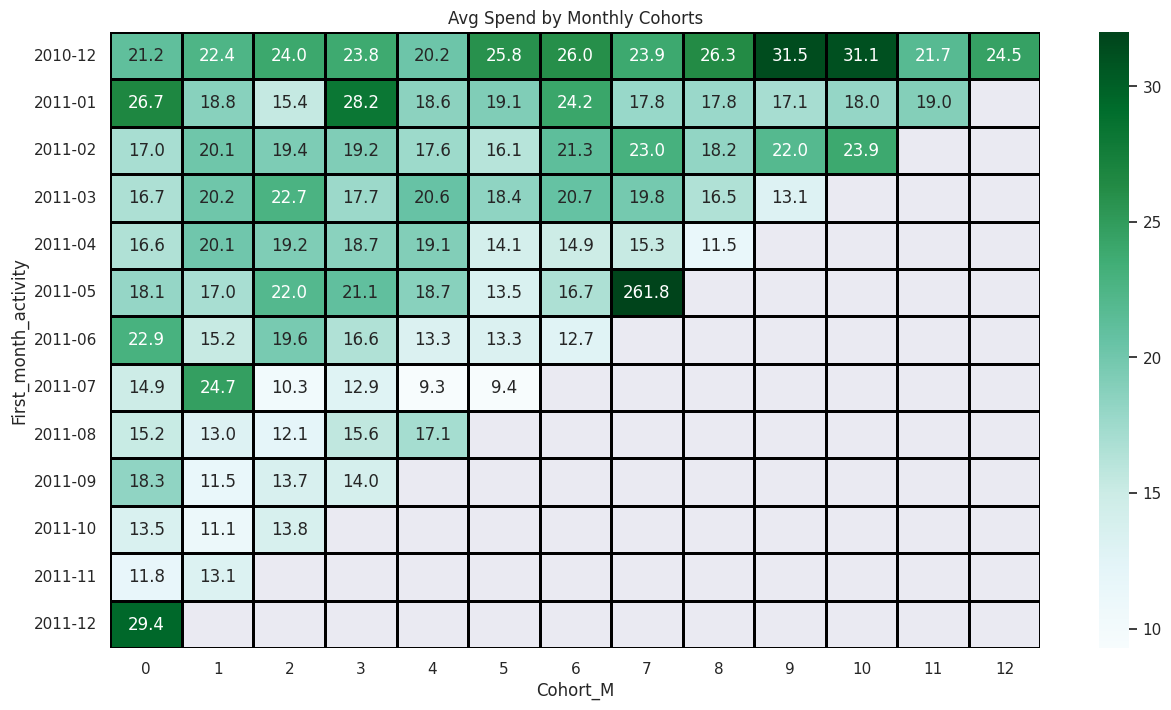

In [259]:
# Lets take a view the average price across the time

buyers_group = df_uk.groupby(['First_month_activity','Cohort_M'])['Total_spend'].mean().reset_index()

# adjust dates for a clear graphic
buyers_group['First_month_activity'] = buyers_group['First_month_activity'].dt.strftime('%Y-%m')

# lets create our cohort pivot 

avg_ammount_pivot = buyers_group.pivot_table(
    index='First_month_activity',
    columns='Cohort_M',
    values='Total_spend'
)

sns.set(style='dark')
plt.figure(figsize=(15,8))
plt.title('Avg Spend by Monthly Cohorts')
sns.heatmap(avg_ammount_pivot, annot=True, fmt='.1f', linewidths=1, linecolor= 'black',vmax=32,cmap='BuGn')
plt.show()


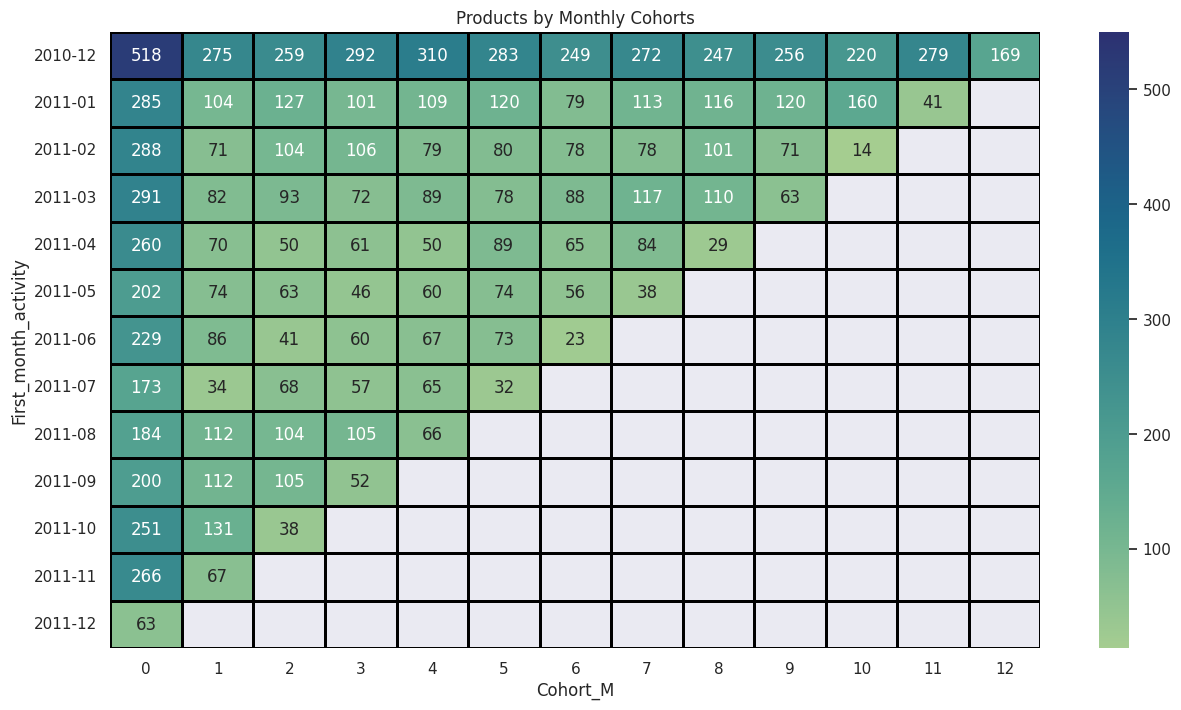

In [260]:
# Let's check the number of different products bought across time and across cohorts.

amount_products = df_uk.groupby(['First_month_activity','Cohort_M'])['StockCode'].nunique().reset_index()
#amount_products.head()

# adjust dates for a clear graphic
amount_products['First_month_activity'] = amount_products['First_month_activity'].dt.strftime('%Y-%m')

pivot_products = amount_products.pivot_table(
    index='First_month_activity',
    columns='Cohort_M',
    values='StockCode'
)

plt.figure(figsize=(15,8))
plt.title('Products by Monthly Cohorts')
sns.heatmap(pivot_products, annot=True, fmt='.0f', linewidths=1, linecolor= 'black',vmax=550,cmap='crest')
plt.show()

In [261]:
# Now lets take a look of Top 10 Products

top_10_products = df_uk.groupby('StockCode',)['Quantity'].sum().sort_values(ascending=False).head(10)
top_10_products


StockCode
85099B    41878
85123A    34687
85099F    15765
85099C    12121
84970S     7784
M          6894
75049L     6809
82494L     6006
16161P     5851
16156S     5400
Name: Quantity, dtype: int64

In [262]:
# Create a list with top products

top_products= top_10_products.index.tolist()
df_top = df_uk[df_uk['StockCode'].isin(top_products)].copy()

df_top['YearMonth']= df_top['InvoiceDate'].dt.to_period('M')
df_top['YearMonth'] = df_top['YearMonth'].dt.to_timestamp()


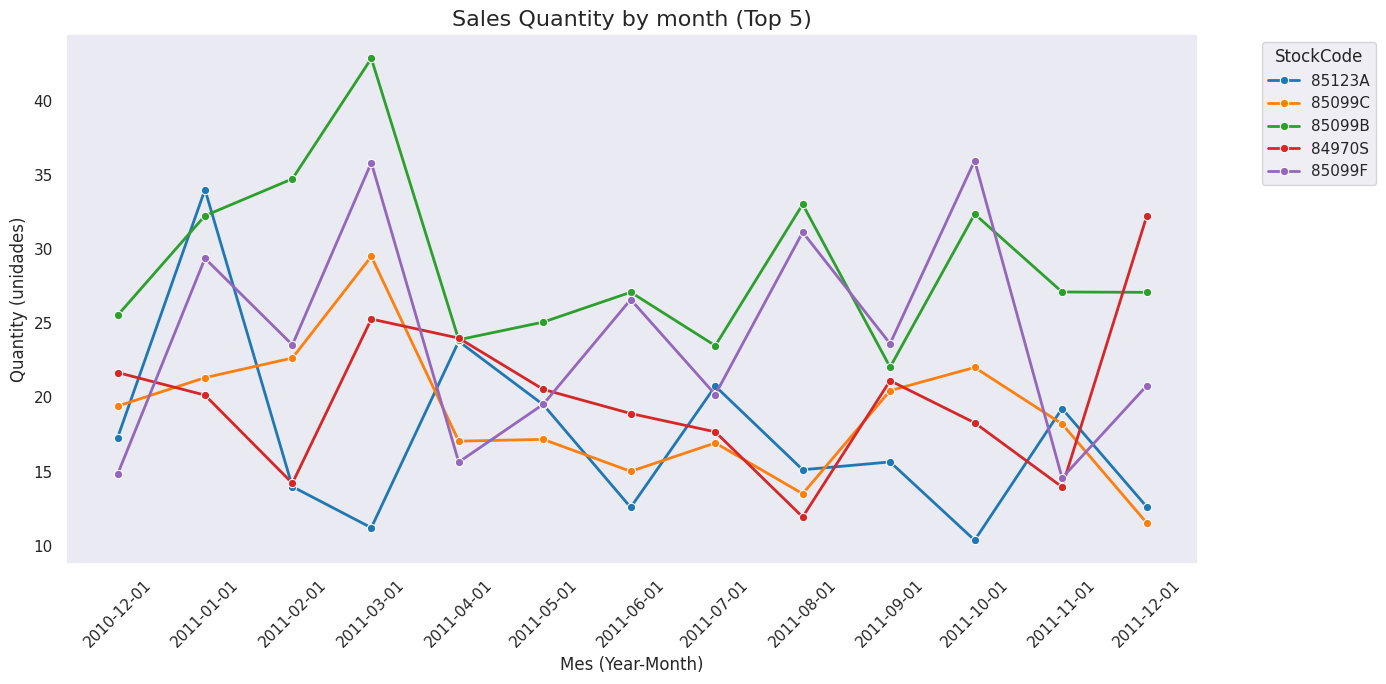

In [263]:
# Calcular top 5 StockCodes por ventas totales
top5_codes = df_top.groupby('StockCode')['Quantity'].sum().nlargest(5).index

# Filtrar solo esos top 5
df_top5 = df_top[df_top['StockCode'].isin(top5_codes)]

# Unic Month
unique_month = sorted(df_top5['YearMonth'].unique())

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_top5,
    x='YearMonth',
    y='Quantity',
    hue='StockCode',
    marker='o',
    palette='tab10',
    linewidth=2,
    errorbar=None
)

#plt.yscale('log')  # escala log para manejar diferencias grandes
ticks_to_show = df_top5['YearMonth'].drop_duplicates().iloc[::3]
plt.xticks(unique_month, rotation=45)
plt.title('Sales Quantity by month (Top 5)', fontsize=16)
plt.xlabel('Mes (Year-Month)', fontsize=12)
plt.ylabel('Quantity (unidades)', fontsize=12)
plt.legend(title='StockCode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### RFM

The RFM model is a classic customer segmentation technique used in marketing and CRM to categorize customers based on their purchase behavior. RFM stands for:

R – Recency: How recently a customer made a purchase.

F – Frequency: How often the customer purchases.

M – Monetary: How much money the customer spends.

By combining these three metrics, businesses can identify valuable customers, loyal buyers, at-risk customers, and inactive customers, which helps guide marketing and retention strategies.

#### Recency

In [264]:
# Period time of the data

print(f'First_order {df_uk['InvoiceDate'].min()}')
print(f'Last_order {df_uk['InvoiceDate'].max()}')

First_order 2010-12-01 08:26:00
Last_order 2011-12-09 12:49:00


In [265]:
# lets look for the recency of the customers
customers_rfm = df_uk.groupby('CustomerID')['InvoiceDate'].max().reset_index()
customers_rfm.columns = ['CustomerID','Last_order_date']
# To calculate the recency we need to take the max date of the dataset and subtract the last order date of each customer
customers_rfm['Recency'] = (df_uk['InvoiceDate'].max() - customers_rfm['Last_order_date']).dt.days
customers_rfm.head()

,CustomerID,Last_order_date,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12747.0,2011-12-07 14:34:00,1
2,12748.0,2011-12-09 12:20:00,0
3,12749.0,2011-12-06 09:56:00,3
4,12820.0,2011-12-06 15:12:00,2


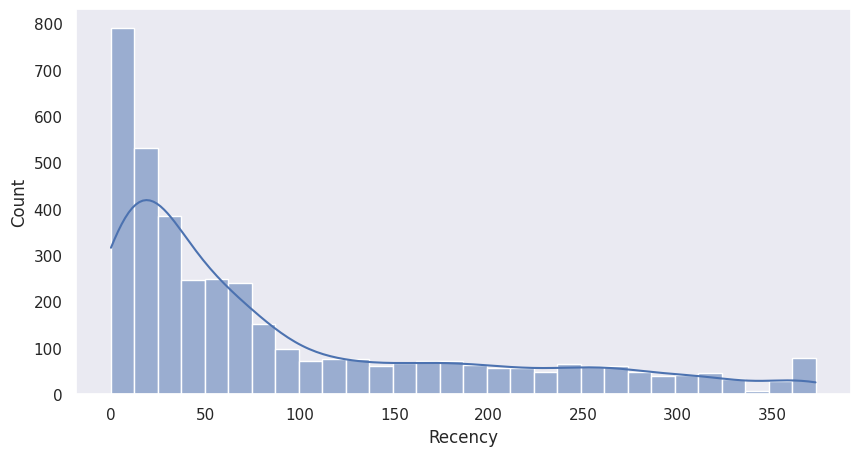

In [266]:
plt.figure(figsize=(10,5))
sns.histplot(customers_rfm['Recency'],bins=30, kde=True)
plt.show()

In [267]:
customers_rfm['Recency'].describe()

count    3920.000000
mean       91.208418
std        99.533854
min         0.000000
25%        17.000000
50%        50.000000
75%       142.000000
max       373.000000
Name: Recency, dtype: float64

The recency distribution shows that customers purchased, on average, about 91 days ago, although the distribution is quite spread out (standard deviation ≈ 99 days).

The median recency is 50 days, which indicates that half of the customers made a purchase within the last two months. Additionally, 25% of customers purchased within the last 17 days, showing a group of very recently active customers.

However, 25% of customers have not made a purchase in more than 142 days, and the maximum recency reaches 373 days, suggesting that a significant portion of customers may be inactive or at risk of churn.

Overall, the data suggests that while a large portion of customers remain relatively active, there is also a long tail of customers who have not purchased for several months and may require re-engagement strategies.

#### Frequency

In [268]:
# Now lets take a look of the frequency of the customers

frequency = df_uk.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID','Frequency']
frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12747.0,11
2,12748.0,209
3,12749.0,5
4,12820.0,4


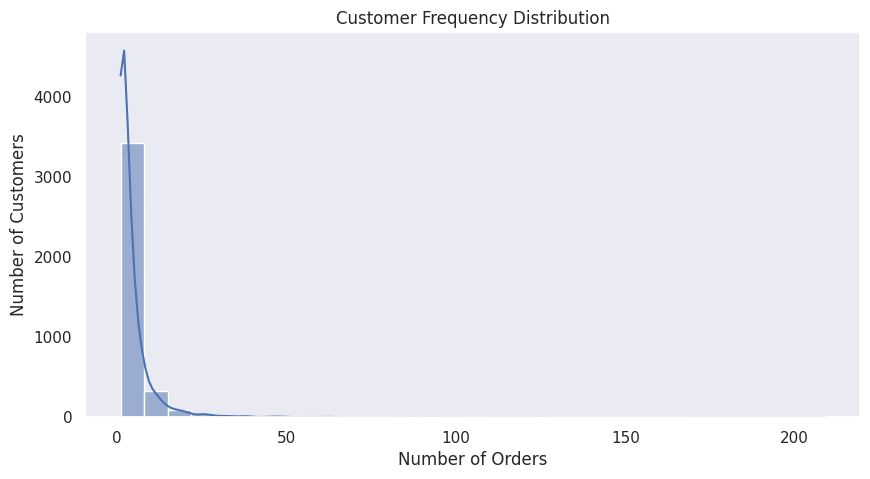

In [269]:
plt.figure(figsize=(10,5))
sns.histplot(frequency['Frequency'], bins=30, kde=True)
plt.title('Customer Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

In [270]:
frequency['Frequency'].describe()

count    3920.000000
mean        4.246429
std         7.199202
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Frequency, dtype: float64

The frequency distribution shows that customers make an average of 4.25 purchases, although the variability is quite high (standard deviation ≈ 7.2), indicating that purchasing behavior differs significantly across customers.

The median frequency is 2, which means that half of the customers have made two or fewer purchases, suggesting that many customers are relatively new or infrequent buyers.

Additionally, 25% of customers have made only one purchase, indicating a large group of one-time buyers. On the other hand, 25% of customers have made five or more purchases, representing a segment of more engaged customers.

The maximum frequency reaches 209 purchases, which likely corresponds to highly loyal or business customers with very frequent transactions.

Overall, the frequency distribution suggests that while a large portion of customers purchase only once or twice, there is also a smaller but valuable group of highly active customers who contribute significantly to repeat sales.

In [271]:
# merge both datasets

customers_rfm = customers_rfm.merge(frequency, on='CustomerID')
customers_rfm.head()

,CustomerID,Last_order_date,Recency,Frequency
0,12346.0,2011-01-18 10:01:00,325,1
1,12747.0,2011-12-07 14:34:00,1,11
2,12748.0,2011-12-09 12:20:00,0,209
3,12749.0,2011-12-06 09:56:00,3,5
4,12820.0,2011-12-06 15:12:00,2,4


#### Monetary

In [272]:
# how much do the customers spends

monetary = df_uk.groupby('CustomerID')['Total_spend'].sum().reset_index()
monetary.columns = ['CustomerID','Monetary']
monetary.head()


,CustomerID,Monetary
0,12346.0,77183.60
1,12747.0,4196.01
2,12748.0,33053.19
3,12749.0,4090.88
4,12820.0,942.34


Text(0.5, 0, 'Total Spend')

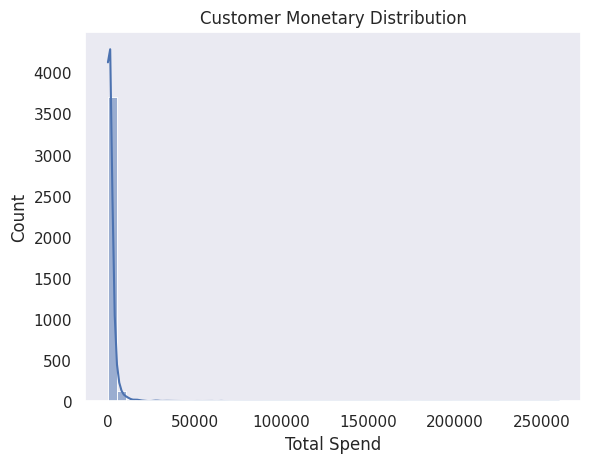

In [273]:
sns.histplot(monetary['Monetary'], bins=50, kde=True)
plt.title('Customer Monetary Distribution')
plt.xlabel('Total Spend') 

In [274]:
monetary['Monetary'].describe()

count      3920.000000
mean       1858.424654
std        7478.631256
min           3.750000
25%         298.185000
50%         644.975000
75%        1571.285000
max      259657.300000
Name: Monetary, dtype: float64

The monetary distribution shows that customers spend an average of 1,858, although the very large standard deviation (≈ 7,479) indicates a highly skewed distribution with significant differences in customer spending behavior.

The median spending is 644.98, meaning that half of the customers have spent less than this amount over the observed period. Additionally, 25% of customers spent less than 298, suggesting a large segment of low-value customers.

On the other hand, 25% of customers spent more than 1,571, representing a more valuable segment. The maximum spending reaches 259,657, which indicates the presence of extremely high-value customers who contribute disproportionately to total revenue.

The large gap between the mean and the median suggests that the revenue distribution is highly skewed, with a small group of customers generating a significant portion of total sales. Identifying and retaining these high-value customers is critical for maximizing business profitability.

In [275]:
percentile = np.percentile(monetary['Monetary'],[90,95,99])
print('Percentiles 90/95/99:', percentile)

Percentiles 90/95/99: [ 3410.912   5488.444  17281.1581]


The percentile analysis shows that 90% of customers spend less than 3,410, while the top 10% of customers spend more than this amount, indicating a relatively small but valuable high-spending segment.

At the 95th percentile, customers spend up to 5,488, meaning that only 5% of customers exceed this level of spending.

The 99th percentile reaches 17,281, which indicates the presence of extremely high-value customers whose spending is far above the typical customer. These extreme values explain the strong skewness observed in the monetary distribution.

*** Business Insight

This distribution suggests that a small proportion of customers contributes disproportionately to total revenue, which is a common pattern in retail datasets and often aligns with the Pareto principle (80/20 rule).

In [276]:
monetary = monetary.sort_values(by= 'Monetary', ascending=False)

#sumcum
monetary['cum_revenue'] = monetary['Monetary'].cumsum()
monetary['cum_revenue_perc'] = monetary['cum_revenue'] / monetary['Monetary'].sum() * 100

monetary.head()

,CustomerID,Monetary,cum_revenue,cum_revenue_perc
3783,18102.0,259657.30,259657.30,3.564261
3314,17450.0,194390.79,454048.09,6.232623
2598,16446.0,168472.50,622520.59,8.545209
3356,17511.0,91062.38,713582.97,9.795203
2294,16029.0,80850.84,794433.81,10.905026


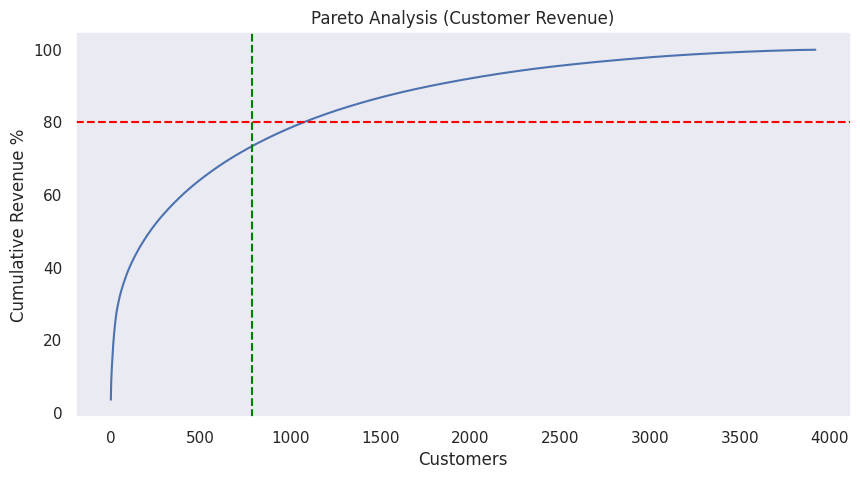

In [277]:
plt.figure(figsize=(10,5))
plt.plot(monetary['cum_revenue_perc'].values)

plt.axhline(80, color='red', linestyle='--')
plt.axvline(len(monetary)*0.2, color='green', linestyle='--')

plt.title("Pareto Analysis (Customer Revenue)")
plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue %")

plt.show()

Pareto Analysis – Customer Revenue

The Pareto analysis illustrates the cumulative contribution of customers to total revenue. The curve shows that revenue is unevenly distributed among customers, with a relatively small portion generating a large share of sales.

From the chart, we can observe that:

Approximately 20% of customers generate around 75–80% of total revenue.

The remaining 80% of customers contribute only about 20–25% of the revenue.

The curve rises steeply at the beginning, indicating that top customers have a disproportionately high impact on revenue.

This pattern is consistent with the Pareto principle (80/20 rule), which commonly appears in retail and e-commerce datasets.

In [278]:
# merge both datasets
customers_rfm = customers_rfm.merge(monetary, on='CustomerID')
customers_rfm.head()

,CustomerID,Last_order_date,Recency,Frequency,Monetary,cum_revenue,cum_revenue_perc
0,12346.0,2011-01-18 10:01:00,325,1,77183.60,871617.410,11.964509
1,12747.0,2011-12-07 14:34:00,1,11,4196.01,3938421.070,54.061877
2,12748.0,2011-12-09 12:20:00,0,209,33053.19,1801878.380,24.734005
3,12749.0,2011-12-06 09:56:00,3,5,4090.88,3987942.530,54.741648
4,12820.0,2011-12-06 15:12:00,2,4,942.34,6328670.911,86.872334


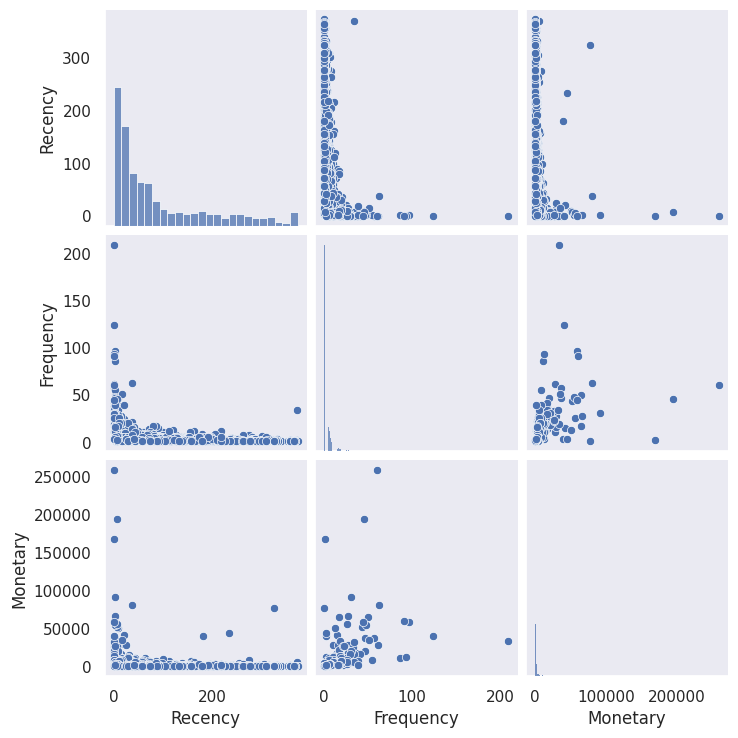

In [279]:
sns.pairplot(customers_rfm[['Recency','Frequency','Monetary']])
plt.show()

Relationship Between Frequency and Monetary

There appears to be a positive relationship between Frequency and Monetary. Customers who purchase more frequently tend to spend more overall, which is expected since repeat customers generate higher cumulative revenue.

Customers with low recency (recent purchases) tend to have higher purchase frequency, while customers with high recency values tend to have low frequency. This suggests that customers who buy often also tend to remain active.

Customers with recent purchases tend to generate higher monetary values, whereas customers who have not purchased for a long time generally have lower total spending.

#### K-means algorithm

In [280]:
# The data is skewed, so we are going to apply log transformation to the data
customers_rfm_log = customers_rfm.copy()

# apply log transformation to the data
customers_rfm_log[['Recency','Frequency','Monetary']] = np.log1p(
    customers_rfm_log[['Recency','Frequency','Monetary']]
)

In [281]:
customers_rfm_log.head()

,CustomerID,Last_order_date,Recency,Frequency,Monetary,cum_revenue,cum_revenue_perc
0,12346.0,2011-01-18 10:01:00,5.786897,0.693147,11.253955,871617.410,11.964509
1,12747.0,2011-12-07 14:34:00,0.693147,2.484907,8.342128,3938421.070,54.061877
2,12748.0,2011-12-09 12:20:00,0.000000,5.347108,10.405904,1801878.380,24.734005
3,12749.0,2011-12-06 09:56:00,1.386294,1.791759,8.316760,3987942.530,54.741648
4,12820.0,2011-12-06 15:12:00,1.098612,1.609438,6.849427,6328670.911,86.872334


In [282]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


scaler = StandardScaler()

# Standardize the data (Just the columns that we are going to use for the clustering)
cols_to_scale = ['Recency','Frequency','Monetary']

# Create a new DataFrame with the scaled values and the same index
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(customers_rfm_log[cols_to_scale]),
    columns=cols_to_scale,
    index=customers_rfm_log.index
)

#customers_rfm_scaled = scaler.fit_transform(customers_rfm_log)

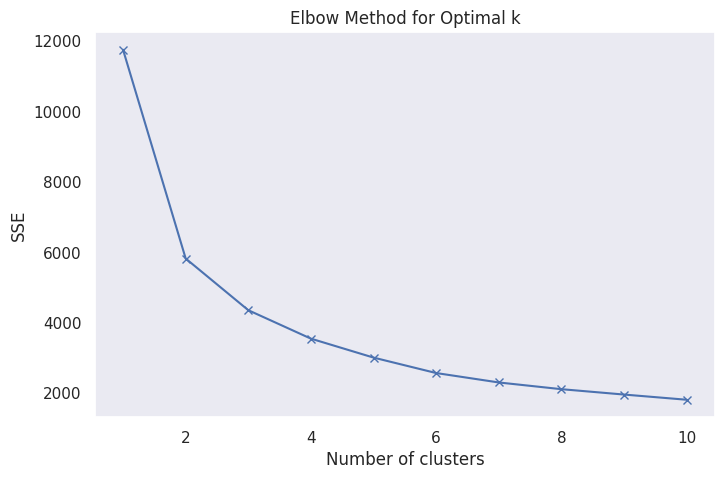

In [283]:
sse = []

K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, sse, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()

In [284]:
# Choose k=4 (as we can see on the graph, the elbow is on 4 clusters)
kmeans = KMeans(n_clusters=4, random_state=0)

# fit the model
customers_rfm_log['Cluster']= kmeans.fit_predict(rfm_scaled)
customers_rfm_log.head()

,CustomerID,Last_order_date,Recency,Frequency,Monetary,cum_revenue,cum_revenue_perc,Cluster
0,12346.0,2011-01-18 10:01:00,5.786897,0.693147,11.253955,871617.410,11.964509,1
1,12747.0,2011-12-07 14:34:00,0.693147,2.484907,8.342128,3938421.070,54.061877,2
2,12748.0,2011-12-09 12:20:00,0.000000,5.347108,10.405904,1801878.380,24.734005,2
3,12749.0,2011-12-06 09:56:00,1.386294,1.791759,8.316760,3987942.530,54.741648,2
4,12820.0,2011-12-06 15:12:00,1.098612,1.609438,6.849427,6328670.911,86.872334,3


In [285]:
# Check cluster centers. This helps interpret segments.

cluster_centers = kmeans.cluster_centers_
cluster_centers_df = pd.DataFrame(cluster_centers, columns=['Recency', 'Frequency', 'Monetary'])
print(cluster_centers_df)

    Recency  Frequency  Monetary
0  0.877036  -0.754555 -0.762586
1  0.045075   0.431901  0.588694
2 -1.370036   1.714352  1.448021
3 -0.743581  -0.431183 -0.430610


In [286]:
cluster_centers_exp = np.exp(cluster_centers)
print(cluster_centers_exp)

[[2.40376397 0.47021992 0.46645847]
 [1.04610679 1.54018327 1.80163397]
 [0.25409778 5.55307501 4.25468423]
 [0.47540864 0.64973987 0.65011237]]


In [287]:
# Now we can check the mean of each cluster to interpret the segments
customers_rfm_log.groupby('Cluster').mean()

,CustomerID,Last_order_date,Recency,Frequency,Monetary,cum_revenue,cum_revenue_perc
Cluster,,,,,,,
0,15564.677505,2011-06-11 10:36:38.142003968,5.018840,0.830529,5.591850,7.029605e+06,96.493911
1,15484.498134,2011-10-08 18:37:31.287313408,3.833217,1.638646,7.268833,5.710714e+06,78.389768
2,15560.629060,2011-11-29 12:54:12.000000000,1.800007,2.515873,8.342351,4.117922e+06,56.525850
3,15667.929894,2011-11-20 04:38:28.809523968,2.684213,1.055097,6.005291,6.854106e+06,94.084871


In [288]:
# Columns to analyze
rfm_cols = ['Recency', 'Frequency', 'Monetary']

# average by cluster
cluster_summary = customers_rfm_log.groupby('Cluster')[rfm_cols].mean().sort_values('Monetary', ascending=False)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
2,1.800007,2.515873,8.342351
1,3.833217,1.638646,7.268833
3,2.684213,1.055097,6.005291
0,5.018840,0.830529,5.591850


How to interpret it:

Recency: lower = purchased more recently

Frequency: higher = buys more frequently

Monetary: higher = spends more money

In [289]:
# Now we are going to label the clusters based on the mean values of each cluster
def label_cluster(row):
    if row['Cluster'] == 2:
        return 'High Value'
    elif row['Cluster'] == 1:
        return 'Loyal Customers'
    elif row['Cluster'] == 3:
        return 'Occasional Buyers'
    else:
        return 'New Customers'

customers_rfm_log['Segment'] = customers_rfm_log.apply(label_cluster, axis=1)

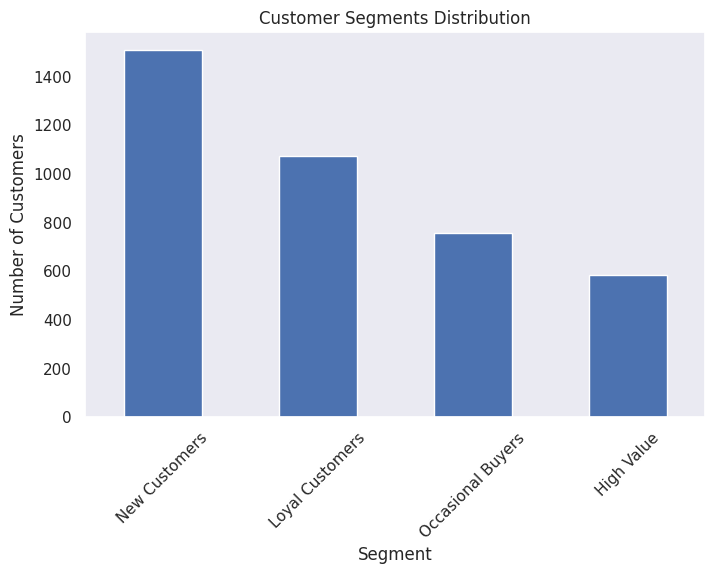

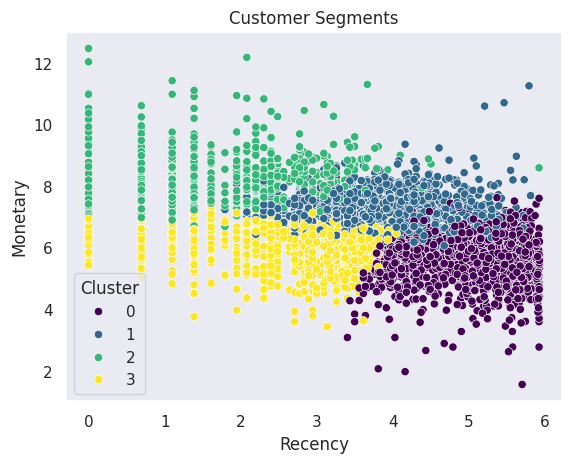

In [290]:
# Now we can check the distribution of the segments
customers_rfm_log['Segment'].value_counts().plot.bar(figsize=(8,5))
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

sns.scatterplot(
    data=customers_rfm_log,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments')
plt.show()

### Conclusions and Recomendations

The analysis reveals a customer base with strong acquisition volume but a critical challenge in short-term retention. Although the "New Customers" segment is the largest (approx. 1,500 users), the cohort matrix shows that 75% to 85% of customers are lost just one month after their first purchase. There is a "golden opportunity" identified in the December 2010 cohort, which maintains exceptional loyalty levels (near 50% after 11 months), suggesting that earlier brand strategies were more effective at building long-term retention. To maximize business value, it is essential to implement a 30-day engagement plan to convert the mass of new users into "High Value" assets (Cluster 2), who currently represent the smallest but most profitable group due to their low recency and high spending patterns.

To mitigate the 80% loss of new customers identified in the cohort analysis, it is suggested to implement a 30-day automation program called the "Repurchase Bridge," focused on transforming the massive acquisition volume into "High Value" assets (Cluster 2). This strategy should consist of a touchpoint flow including a value-driven welcome, a satisfaction check on day 7 to prevent churn, and an exclusive conversion offer on day 22 with a one-week urgency limit; the goal is to incentivize an immediate second transaction that improves recency metrics and replicates the long-term retention success observed in the December 2010 cohort, thereby stabilizing revenue without increasing customer acquisition costs.